In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os

# Path to your data folder in Google Drive
data_path = '/content/drive/MyDrive/telco-churn-analytics/data/'

# List all files in the folder
files = os.listdir(data_path)
print("Files found:")
for f in files:
    print(" -", f)

Files found:
 - Telco_customer_churn_status.csv
 - Telco_customer_churn_population.csv
 - Telco_customer_churn_location.csv
 - CustomerChurn.csv
 - Telco_customer_churn_demographics.csv
 - Telco_customer_churn_services.csv


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# Path to your data folder - update this if your folder name is different
path = '/content/drive/MyDrive/telco-churn-analytics/data/'

# Load all 6 files
demographics = pd.read_csv(path + 'Telco_customer_churn_demographics.csv')
location     = pd.read_csv(path + 'Telco_customer_churn_location.csv')
services     = pd.read_csv(path + 'Telco_customer_churn_services.csv')
status       = pd.read_csv(path + 'Telco_customer_churn_status.csv')
population   = pd.read_csv(path + 'Telco_customer_churn_population.csv')
churn_main   = pd.read_csv(path + 'CustomerChurn.csv')

print("All files loaded successfully!")

All files loaded successfully!


In [5]:
print("demographics :", demographics.shape)

demographics : (7043, 9)


In [6]:
print("location     :", location.shape)

location     : (7043, 10)


In [7]:
print("services     :", services.shape)

services     : (7043, 31)


In [8]:
print("status       :", status.shape)

status       : (7043, 12)


In [9]:
print("population   :", population.shape)

population   : (1671, 3)


In [10]:
print("churn_main   :", churn_main.shape)

churn_main   : (7043, 21)


In [11]:
demographics.head()

,Customer ID,Count,Gender,Age,Under 30,Senior Citizen,Married,Dependents,Number of Dependents
0,8779-QRDMV,1,Male,78,No,Yes,No,No,0
1,7495-OOKFY,1,Female,74,No,Yes,Yes,Yes,1
2,1658-BYGOY,1,Male,71,No,Yes,No,Yes,3
3,4598-XLKNJ,1,Female,78,No,Yes,Yes,Yes,1
4,4846-WHAFZ,1,Female,80,No,Yes,Yes,Yes,1


In [12]:
location.head()

,Location ID,Customer ID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude
0,OXCZEW7397,8779-QRDMV,1,United States,California,Los Angeles,90022,"34.02381, -118.156582",34.023810,-118.156582
1,FCCECI8494,7495-OOKFY,1,United States,California,Los Angeles,90063,"34.044271, -118.185237",34.044271,-118.185237
2,HEHUQY7254,1658-BYGOY,1,United States,California,Los Angeles,90065,"34.108833, -118.229715",34.108833,-118.229715
3,WIUHRF2613,4598-XLKNJ,1,United States,California,Inglewood,90303,"33.936291, -118.332639",33.936291,-118.332639
4,CFEZBF4415,4846-WHAFZ,1,United States,California,Whittier,90602,"33.972119, -118.020188",33.972119,-118.020188


In [13]:
services.head()

,Service ID,Customer ID,Count,Quarter,Referred a Friend,Number of Referrals,Tenure in Months,Offer,Phone Service,Avg Monthly Long Distance Charges,...,Unlimited Data,Contract,Paperless Billing,Payment Method,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue
0,IJKDQVSWH3522,8779-QRDMV,1,Q3,No,0,1,NaN,No,0.00,...,No,Month-to-Month,Yes,Bank Withdrawal,39.65,39.65,0.00,20,0.00,59.65
1,BFKMZJAIE2285,7495-OOKFY,1,Q3,Yes,1,8,Offer E,Yes,48.85,...,Yes,Month-to-Month,Yes,Credit Card,80.65,633.30,0.00,0,390.80,1024.10
2,EIMVJQBMT7187,1658-BYGOY,1,Q3,No,0,18,Offer D,Yes,11.33,...,Yes,Month-to-Month,Yes,Bank Withdrawal,95.45,1752.55,45.61,0,203.94,1910.88
3,EROZQXDUU4979,4598-XLKNJ,1,Q3,Yes,1,25,Offer C,Yes,19.76,...,Yes,Month-to-Month,Yes,Bank Withdrawal,98.50,2514.50,13.43,0,494.00,2995.07
4,GEEYSJUHY6991,4846-WHAFZ,1,Q3,Yes,1,37,Offer C,Yes,6.33,...,Yes,Month-to-Month,Yes,Bank Withdrawal,76.50,2868.15,0.00,0,234.21,3102.36


In [14]:
status.head()

,Status ID,Customer ID,Count,Quarter,Satisfaction Score,Customer Status,Churn Label,Churn Value,Churn Score,CLTV,Churn Category,Churn Reason
0,SWSORB1252,8779-QRDMV,1,Q3,3,Churned,Yes,1,91,5433,Competitor,Competitor offered more data
1,SNAEQA8572,7495-OOKFY,1,Q3,3,Churned,Yes,1,69,5302,Competitor,Competitor made better offer
2,LMBQNN3714,1658-BYGOY,1,Q3,2,Churned,Yes,1,81,3179,Competitor,Competitor made better offer
3,VRZYZI9978,4598-XLKNJ,1,Q3,2,Churned,Yes,1,88,5337,Dissatisfaction,Limited range of services
4,FDNAKX1688,4846-WHAFZ,1,Q3,2,Churned,Yes,1,67,2793,Price,Extra data charges


In [15]:
population.head()

,ID,Zip Code,Population
0,1,90001,"54,492"
1,2,90002,"44,586"
2,3,90003,"58,198"
3,4,90004,"67,852"
4,5,90005,"43,019"


In [16]:
churn_main.head()

,LoyaltyID,Customer ID,Senior Citizen,Partner,Dependents,Tenure,Phone Service,Multiple Lines,Internet Service,Online Security,...,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn
0,318537,7590-VHVEG,No,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,152148,5575-GNVDE,No,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,326527,3668-QPYBK,No,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,845894,7795-CFOCW,No,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,503388,9237-HQITU,No,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [17]:
print("=== Missing Values Per File ===\n")
print("Demographics:\n", demographics.isnull().sum()[demographics.isnull().sum() > 0])
print("\nLocation:\n", location.isnull().sum()[location.isnull().sum() > 0])
print("\nServices:\n", services.isnull().sum()[services.isnull().sum() > 0])
print("\nStatus:\n", status.isnull().sum()[status.isnull().sum() > 0])
print("\nPopulation:\n", population.isnull().sum()[population.isnull().sum() > 0])

=== Missing Values Per File ===

Demographics:
 Series([], dtype: int64)

Location:
 Series([], dtype: int64)

Services:
 Offer            3877
Internet Type    1526
dtype: int64

Status:
 Churn Category    5174
Churn Reason      5174
dtype: int64

Population:
 Series([], dtype: int64)


In [18]:
print("=== Services File Data Types ===")
print(services.dtypes)
print("\n=== Status File Data Types ===")
print(status.dtypes)

=== Services File Data Types ===
Service ID                            object
Customer ID                           object
Count                                  int64
Quarter                               object
Referred a Friend                     object
Number of Referrals                    int64
Tenure in Months                       int64
Offer                                 object
Phone Service                         object
Avg Monthly Long Distance Charges    float64
Multiple Lines                        object
Internet Service                      object
Internet Type                         object
Avg Monthly GB Download                int64
Online Security                       object
Online Backup                         object
Device Protection Plan                object
Premium Tech Support                  object
Streaming TV                          object
Streaming Movies                      object
Streaming Music                       object
Unlimited Data        

In [19]:
print("=== Are These IDs Unique? ===\n")

print("Services file:")
print("  Total rows         :", len(services))
print("  Unique Service IDs :", services['Service ID'].nunique())

print("\nStatus file:")
print("  Total rows         :", len(status))
print("  Unique Status IDs  :", status['Status ID'].nunique())

=== Are These IDs Unique? ===

Services file:
  Total rows         : 7043
  Unique Service IDs : 7043

Status file:
  Total rows         : 7043
  Unique Status IDs  : 7043


In [20]:
# Count how many customers churned, stayed, joined
print("=== Customer Status Breakdown ===")
print(status['Customer Status'].value_counts())
print()

# Calculate churn rate as a percentage
total = len(status)
churned = len(status[status['Customer Status'] == 'Churned'])
churn_rate = (churned / total) * 100

print(f"Total Customers  : {total}")
print(f"Churned          : {churned}")
print(f"Churn Rate       : {churn_rate:.2f}%")

=== Customer Status Breakdown ===
Customer Status
Stayed     4720
Churned    1869
Joined      454
Name: count, dtype: int64

Total Customers  : 7043
Churned          : 1869
Churn Rate       : 26.54%


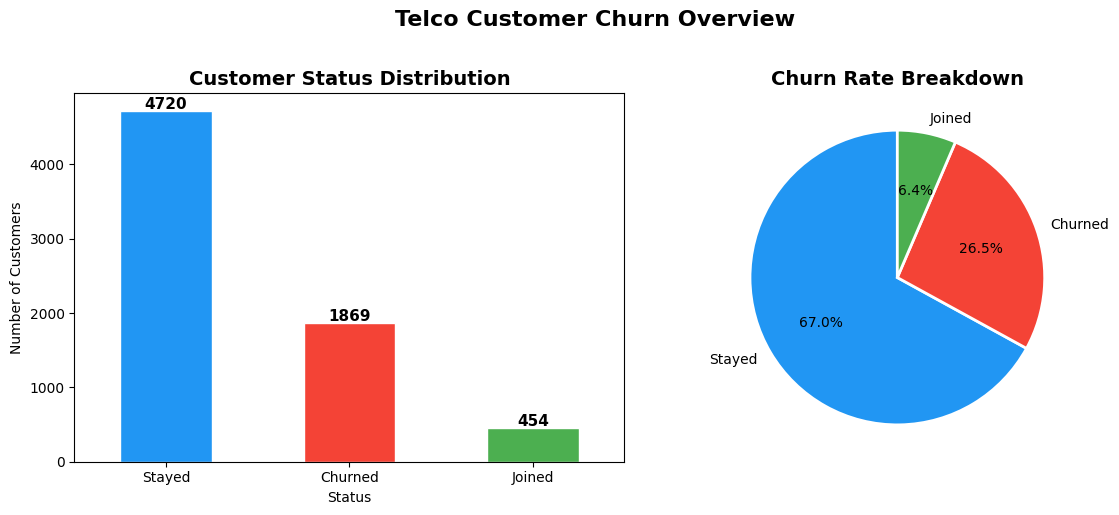

Chart saved to screenshots folder!


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Chart 1 - Customer status bar chart
colors = ['#2196F3', '#F44336', '#4CAF50']
status['Customer Status'].value_counts().plot(
    kind='bar',
    ax=axes[0],
    color=colors,
    edgecolor='white',
    width=0.5
)
axes[0].set_title('Customer Status Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Status')
axes[0].set_ylabel('Number of Customers')
axes[0].tick_params(axis='x', rotation=0)

# Add count labels on top of each bar
for bar in axes[0].patches:
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 30,
        str(int(bar.get_height())),
        ha='center', fontweight='bold', fontsize=11
    )

# Chart 2 - Churn rate pie chart
churn_counts = status['Customer Status'].value_counts()
axes[1].pie(
    churn_counts,
    labels=churn_counts.index,
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[1].set_title('Churn Rate Breakdown', fontsize=14, fontweight='bold')

plt.suptitle('Telco Customer Churn Overview', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/telco-churn-analytics/screenshots/churn_distribution.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved to screenshots folder!")

In [22]:
# Merge all files one by one on Customer ID
master = demographics.merge(location, on='Customer ID') \
                     .merge(services, on='Customer ID', suffixes=('', '_svc')) \
                     .merge(status, on='Customer ID', suffixes=('', '_sts'))

# Check the result
print("=== Master DataFrame ===")
print("Shape            :", master.shape)
print("Total Customers  :", master['Customer ID'].nunique())
print("\nFirst 3 rows:")
master.head(3)

=== Master DataFrame ===
Shape            : (7043, 59)
Total Customers  : 7043

First 3 rows:


,Customer ID,Count_x,Gender,Age,Under 30,Senior Citizen,Married,Dependents,Number of Dependents,Location ID,...,Count_sts,Quarter_sts,Satisfaction Score,Customer Status,Churn Label,Churn Value,Churn Score,CLTV,Churn Category,Churn Reason
0,8779-QRDMV,1,Male,78,No,Yes,No,No,0,OXCZEW7397,...,1,Q3,3,Churned,Yes,1,91,5433,Competitor,Competitor offered more data
1,7495-OOKFY,1,Female,74,No,Yes,Yes,Yes,1,FCCECI8494,...,1,Q3,3,Churned,Yes,1,69,5302,Competitor,Competitor made better offer
2,1658-BYGOY,1,Male,71,No,Yes,No,Yes,3,HEHUQY7254,...,1,Q3,2,Churned,Yes,1,81,3179,Competitor,Competitor made better offer


In [23]:
print("=== All 59 Columns in Master DataFrame ===\n")
for i, col in enumerate(master.columns, 1):
    print(f"{i:2}. {col}")

=== All 59 Columns in Master DataFrame ===

 1. Customer ID
 2. Count_x
 3. Gender
 4. Age
 5. Under 30
 6. Senior Citizen
 7. Married
 8. Dependents
 9. Number of Dependents
10. Location ID
11. Count_y
12. Country
13. State
14. City
15. Zip Code
16. Lat Long
17. Latitude
18. Longitude
19. Service ID
20. Count
21. Quarter
22. Referred a Friend
23. Number of Referrals
24. Tenure in Months
25. Offer
26. Phone Service
27. Avg Monthly Long Distance Charges
28. Multiple Lines
29. Internet Service
30. Internet Type
31. Avg Monthly GB Download
32. Online Security
33. Online Backup
34. Device Protection Plan
35. Premium Tech Support
36. Streaming TV
37. Streaming Movies
38. Streaming Music
39. Unlimited Data
40. Contract
41. Paperless Billing
42. Payment Method
43. Monthly Charge
44. Total Charges
45. Total Refunds
46. Total Extra Data Charges
47. Total Long Distance Charges
48. Total Revenue
49. Status ID
50. Count_sts
51. Quarter_sts
52. Satisfaction Score
53. Customer Status
54. Churn Label

In [24]:
# Calculate churn rate by contract type
contract_churn = master.groupby('Contract')['Churn Value'].mean() * 100

print("=== Churn Rate by Contract Type ===")
for contract, rate in contract_churn.items():
    print(f"{contract:20} : {rate:.1f}%")

=== Churn Rate by Contract Type ===
Month-to-Month       : 45.8%
One Year             : 10.7%
Two Year             : 2.5%


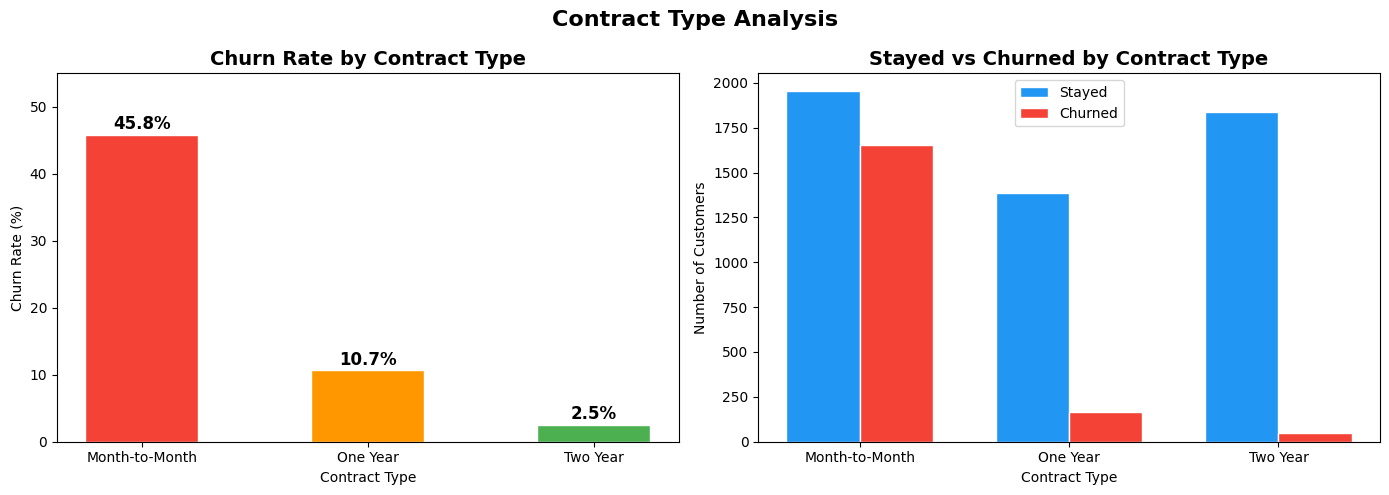

Chart saved!


In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Chart 1: Churn Rate by Contract Type ---
colors = ['#F44336', '#FF9800', '#4CAF50']
bars = axes[0].bar(contract_churn.index, contract_churn.values,
                   color=colors, edgecolor='white', width=0.5)

# Add percentage labels on top of bars
for bar, val in zip(bars, contract_churn.values):
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.8,
        f'{val:.1f}%',
        ha='center', fontweight='bold', fontsize=12
    )

axes[0].set_title('Churn Rate by Contract Type', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Contract Type')
axes[0].set_ylabel('Churn Rate (%)')
axes[0].set_ylim(0, 55)

# --- Chart 2: Customer Count by Contract Type ---
contract_counts = master.groupby('Contract')['Churn Value'].count()
churned_counts  = master[master['Churn Value'] == 1].groupby('Contract')['Churn Value'].count()
stayed_counts   = master[master['Churn Value'] == 0].groupby('Contract')['Churn Value'].count()

x = range(len(contract_counts))
width = 0.35

axes[1].bar([i - width/2 for i in x], stayed_counts.values,
            width=width, label='Stayed', color='#2196F3', edgecolor='white')
axes[1].bar([i + width/2 for i in x], churned_counts.values,
            width=width, label='Churned', color='#F44336', edgecolor='white')

axes[1].set_xticks(list(x))
axes[1].set_xticklabels(contract_counts.index)
axes[1].set_title('Stayed vs Churned by Contract Type', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Contract Type')
axes[1].set_ylabel('Number of Customers')
axes[1].legend()

plt.suptitle('Contract Type Analysis', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/telco-churn-analytics/screenshots/churn_by_contract.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

In [26]:
# Churn rate by internet type
internet_churn = master.groupby('Internet Type')['Churn Value'].mean() * 100

print("=== Churn Rate by Internet Type ===")
for internet, rate in internet_churn.items():
    print(f"{internet:20} : {rate:.1f}%")

=== Churn Rate by Internet Type ===
Cable                : 25.7%
DSL                  : 18.6%
Fiber Optic          : 40.7%


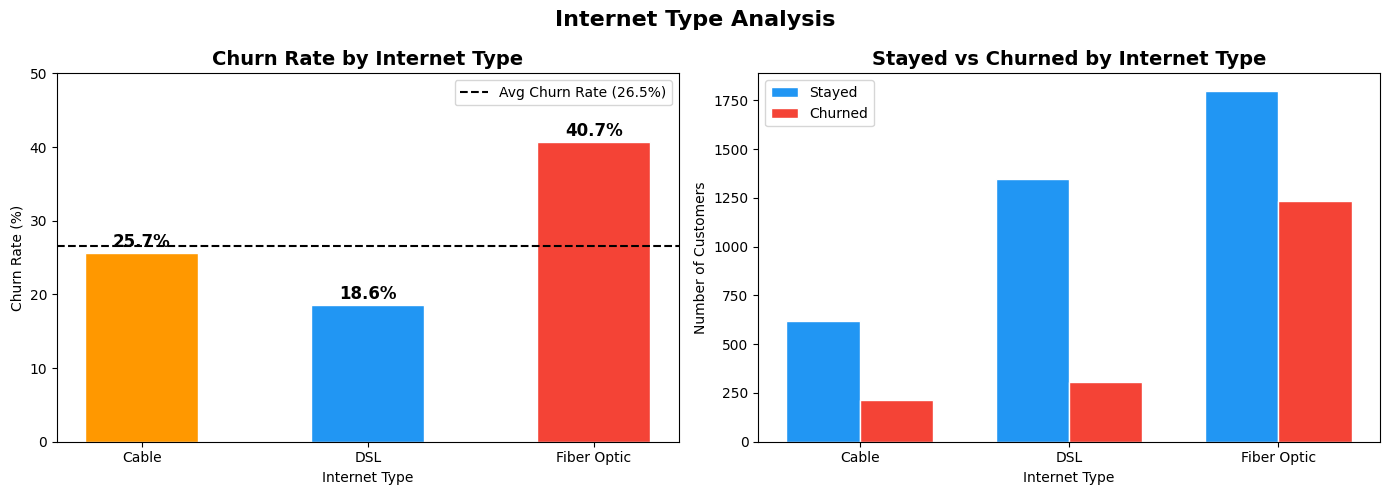

Chart saved!


In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Chart 1: Churn Rate by Internet Type ---
colors_internet = ['#FF9800', '#2196F3', '#F44336']
bars = axes[0].bar(internet_churn.index, internet_churn.values,
                   color=colors_internet, edgecolor='white', width=0.5)

for bar, val in zip(bars, internet_churn.values):
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.8,
        f'{val:.1f}%',
        ha='center', fontweight='bold', fontsize=12
    )

# Add a horizontal line showing overall average churn rate
axes[0].axhline(y=26.54, color='black', linestyle='--', linewidth=1.5, label='Avg Churn Rate (26.5%)')
axes[0].legend()
axes[0].set_title('Churn Rate by Internet Type', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Internet Type')
axes[0].set_ylabel('Churn Rate (%)')
axes[0].set_ylim(0, 50)

# --- Chart 2: Customer Count Stayed vs Churned by Internet Type ---
churned_internet = master[master['Churn Value'] == 1].groupby('Internet Type')['Churn Value'].count()
stayed_internet  = master[master['Churn Value'] == 0].groupby('Internet Type')['Churn Value'].count()

x = range(len(internet_churn))
width = 0.35

axes[1].bar([i - width/2 for i in x], stayed_internet.values,
            width=width, label='Stayed', color='#2196F3', edgecolor='white')
axes[1].bar([i + width/2 for i in x], churned_internet.values,
            width=width, label='Churned', color='#F44336', edgecolor='white')

axes[1].set_xticks(list(x))
axes[1].set_xticklabels(internet_churn.index)
axes[1].set_title('Stayed vs Churned by Internet Type', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Internet Type')
axes[1].set_ylabel('Number of Customers')
axes[1].legend()

plt.suptitle('Internet Type Analysis', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/telco-churn-analytics/screenshots/churn_by_internet.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

In [29]:
# Filter only churned customers
churned_customers = master[master['Churn Value'] == 1]

print("=== All Churn Reasons ===\n")
all_reasons = churned_customers['Churn Reason'].value_counts()
print(all_reasons)
print(f"\nTotal unique churn reasons : {all_reasons.shape[0]}")
print(f"Total churned customers    : {all_reasons.sum()}")

=== All Churn Reasons ===

Churn Reason
Competitor had better devices                313
Competitor made better offer                 311
Attitude of support person                   220
Don't know                                   130
Competitor offered more data                 117
Competitor offered higher download speeds    100
Attitude of service provider                  94
Price too high                                78
Product dissatisfaction                       77
Network reliability                           72
Long distance charges                         64
Service dissatisfaction                       63
Moved                                         46
Extra data charges                            39
Limited range of services                     37
Poor expertise of online support              31
Lack of affordable download/upload speed      30
Lack of self-service on Website               29
Poor expertise of phone support               12
Deceased                     

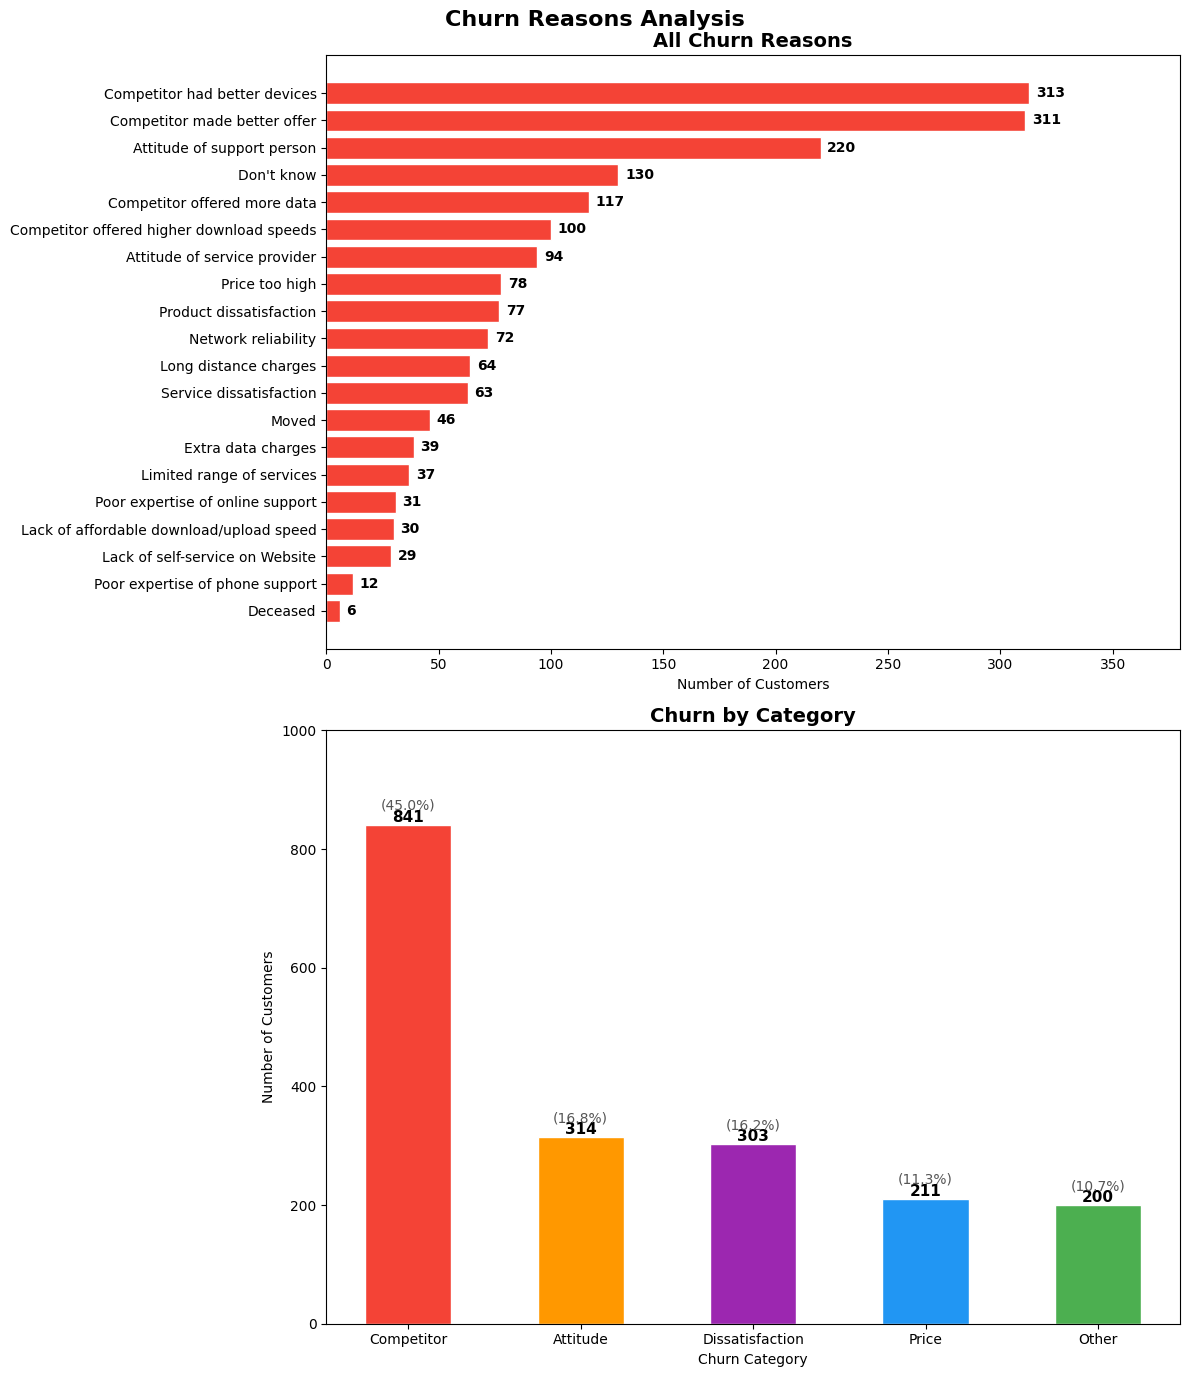

Chart saved!


In [30]:
fig, axes = plt.subplots(2, 1, figsize=(12, 14))

# --- Chart 1: All Individual Churn Reasons ---
colors_reasons = ['#F44336'] * len(all_reasons)
bars = axes[0].barh(all_reasons.index[::-1], all_reasons.values[::-1],
                    color=colors_reasons, edgecolor='white')

for bar, val in zip(bars, all_reasons.values[::-1]):
    axes[0].text(
        bar.get_width() + 3,
        bar.get_y() + bar.get_height()/2,
        str(val),
        va='center', fontweight='bold', fontsize=10
    )

axes[0].set_title('All Churn Reasons', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Number of Customers')
axes[0].set_xlim(0, 380)

# --- Chart 2: Churn by Category ---
category_churn = churned_customers['Churn Category'].value_counts()

colors_cat = ['#F44336', '#FF9800', '#9C27B0', '#2196F3', '#4CAF50']
bars2 = axes[1].bar(category_churn.index, category_churn.values,
                    color=colors_cat, edgecolor='white', width=0.5)

for bar, val in zip(bars2, category_churn.values):
    # Add count on top
    axes[1].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 5,
        str(val),
        ha='center', fontweight='bold', fontsize=11
    )
    # Add percentage below count
    pct = (val / len(churned_customers)) * 100
    axes[1].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 25,
        f'({pct:.1f}%)',
        ha='center', fontsize=10, color='#555555'
    )

axes[1].set_title('Churn by Category', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Churn Category')
axes[1].set_ylabel('Number of Customers')
axes[1].set_ylim(0, 1000)

plt.suptitle('Churn Reasons Analysis', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/telco-churn-analytics/screenshots/churn_reasons.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

In [31]:
print("=== Tenure Statistics ===\n")
print("Overall:")
print(master['Tenure in Months'].describe())

print("\nChurned Customers:")
print(master[master['Churn Value'] == 1]['Tenure in Months'].describe())

print("\nStayed Customers:")
print(master[master['Churn Value'] == 0]['Tenure in Months'].describe())

=== Tenure Statistics ===

Overall:
count    7043.000000
mean       32.386767
std        24.542061
min         1.000000
25%         9.000000
50%        29.000000
75%        55.000000
max        72.000000
Name: Tenure in Months, dtype: float64

Churned Customers:
count    1869.000000
mean       17.979133
std        19.531123
min         1.000000
25%         2.000000
50%        10.000000
75%        29.000000
max        72.000000
Name: Tenure in Months, dtype: float64

Stayed Customers:
count    5174.000000
mean       37.591225
std        24.085029
min         1.000000
25%        15.000000
50%        38.000000
75%        61.000000
max        72.000000
Name: Tenure in Months, dtype: float64


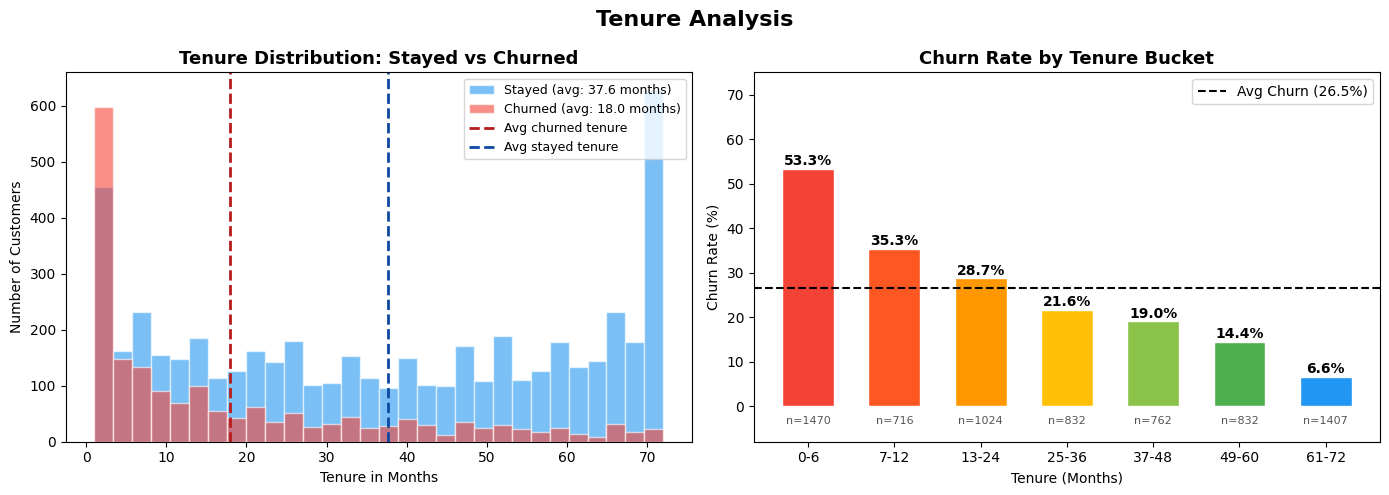

Chart saved!


In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Chart 1: Tenure Distribution Histogram ---
axes[0].hist(master[master['Churn Value'] == 0]['Tenure in Months'],
             bins=30, alpha=0.6, color='#2196F3', label=f'Stayed (avg: 37.6 months)', edgecolor='white')
axes[0].hist(master[master['Churn Value'] == 1]['Tenure in Months'],
             bins=30, alpha=0.6, color='#F44336', label=f'Churned (avg: 18.0 months)', edgecolor='white')

axes[0].axvline(x=17.98, color='#B71C1C', linestyle='--', linewidth=2, label='Avg churned tenure')
axes[0].axvline(x=37.59, color='#0D47A1', linestyle='--', linewidth=2, label='Avg stayed tenure')

axes[0].set_title('Tenure Distribution: Stayed vs Churned', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Tenure in Months')
axes[0].set_ylabel('Number of Customers')
axes[0].legend(fontsize=9)

# --- Chart 2: Churn Rate by Tenure Bucket ---
# Create tenure buckets
bins = [0, 6, 12, 24, 36, 48, 60, 72]
labels = ['0-6', '7-12', '13-24', '25-36', '37-48', '49-60', '61-72']

master['Tenure Bucket'] = pd.cut(master['Tenure in Months'],
                                  bins=bins, labels=labels)

tenure_churn = master.groupby('Tenure Bucket', observed=True)['Churn Value'].mean() * 100
tenure_count = master.groupby('Tenure Bucket', observed=True)['Churn Value'].count()

colors_tenure = ['#F44336', '#FF5722', '#FF9800', '#FFC107', '#8BC34A', '#4CAF50', '#2196F3']
bars = axes[1].bar(tenure_churn.index, tenure_churn.values,
                   color=colors_tenure, edgecolor='white', width=0.6)

for bar, val, count in zip(bars, tenure_churn.values, tenure_count.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8,
                 f'{val:.1f}%', ha='center', fontweight='bold', fontsize=10)
    axes[1].text(bar.get_x() + bar.get_width()/2, -4,
                 f'n={count}', ha='center', fontsize=8, color='#555555')

axes[1].axhline(y=26.54, color='black', linestyle='--', linewidth=1.5, label='Avg Churn (26.5%)')
axes[1].set_title('Churn Rate by Tenure Bucket', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Tenure (Months)')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].set_ylim(-8, 75)
axes[1].legend()

plt.suptitle('Tenure Analysis', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/telco-churn-analytics/screenshots/churn_by_tenure.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

In [33]:
# List of columns to drop
cols_to_drop = [
    'Count_x', 'Count_y', 'Count', 'Count_sts',  # always 1
    'Quarter', 'Quarter_sts',                      # same value every row
    'Service ID', 'Status ID', 'Location ID',      # meaningless IDs
    'Lat Long',                                    # redundant with Latitude/Longitude
    'Country', 'State',                            # no variation, all USA/California
    'Churn Label'                                  # duplicate of Churn Value
]

In [34]:
# Drop them and store in new variable df
df = master.drop(columns=cols_to_drop)

print("=== After Dropping Useless Columns ===")
print(f"Before : {master.shape[1]} columns")
print(f"After  : {df.shape[1]} columns")
print(f"Dropped: {master.shape[1] - df.shape[1]} columns")
print("\nRemaining columns:")
for i, col in enumerate(df.columns, 1):
    print(f"{i:2}. {col}")

=== After Dropping Useless Columns ===
Before : 60 columns
After  : 47 columns
Dropped: 13 columns

Remaining columns:
 1. Customer ID
 2. Gender
 3. Age
 4. Under 30
 5. Senior Citizen
 6. Married
 7. Dependents
 8. Number of Dependents
 9. City
10. Zip Code
11. Latitude
12. Longitude
13. Referred a Friend
14. Number of Referrals
15. Tenure in Months
16. Offer
17. Phone Service
18. Avg Monthly Long Distance Charges
19. Multiple Lines
20. Internet Service
21. Internet Type
22. Avg Monthly GB Download
23. Online Security
24. Online Backup
25. Device Protection Plan
26. Premium Tech Support
27. Streaming TV
28. Streaming Movies
29. Streaming Music
30. Unlimited Data
31. Contract
32. Paperless Billing
33. Payment Method
34. Monthly Charge
35. Total Charges
36. Total Refunds
37. Total Extra Data Charges
38. Total Long Distance Charges
39. Total Revenue
40. Satisfaction Score
41. Customer Status
42. Churn Value
43. Churn Score
44. CLTV
45. Churn Category
46. Churn Reason
47. Tenure Bucket


In [35]:
print("=== Missing Values in df ===\n")
print(df.isnull().sum()[df.isnull().sum() > 0])

=== Missing Values in df ===

Offer             3877
Internet Type     1526
Churn Category    5174
Churn Reason      5174
dtype: int64


In [36]:
# Fill missing values with meaningful labels
df['Offer']          = df['Offer'].fillna('No Offer')
df['Internet Type']  = df['Internet Type'].fillna('No Internet')
df['Churn Category'] = df['Churn Category'].fillna('Not Applicable')
df['Churn Reason']   = df['Churn Reason'].fillna('Not Applicable')

# Verify no missing values remain
remaining = df.isnull().sum()[df.isnull().sum() > 0]

print("=== Missing Values After Fix ===\n")
if len(remaining) == 0:
    print("No missing values remaining! All columns are clean.")
else:
    print(remaining)

=== Missing Values After Fix ===

No missing values remaining! All columns are clean.


In [37]:
# Rename all columns - replace spaces with underscores, lowercase everything
df.columns = df.columns.str.strip()\
                        .str.lower()\
                        .str.replace(' ', '_')\
                        .str.replace('/', '_')\
                        .str.replace('-', '_')

print("=== Renamed Columns ===\n")
for i, col in enumerate(df.columns, 1):
    print(f"{i:2}. {col}")

=== Renamed Columns ===

 1. customer_id
 2. gender
 3. age
 4. under_30
 5. senior_citizen
 6. married
 7. dependents
 8. number_of_dependents
 9. city
10. zip_code
11. latitude
12. longitude
13. referred_a_friend
14. number_of_referrals
15. tenure_in_months
16. offer
17. phone_service
18. avg_monthly_long_distance_charges
19. multiple_lines
20. internet_service
21. internet_type
22. avg_monthly_gb_download
23. online_security
24. online_backup
25. device_protection_plan
26. premium_tech_support
27. streaming_tv
28. streaming_movies
29. streaming_music
30. unlimited_data
31. contract
32. paperless_billing
33. payment_method
34. monthly_charge
35. total_charges
36. total_refunds
37. total_extra_data_charges
38. total_long_distance_charges
39. total_revenue
40. satisfaction_score
41. customer_status
42. churn_value
43. churn_score
44. cltv
45. churn_category
46. churn_reason
47. tenure_bucket


In [38]:
print("=== Current Data Types ===\n")
print(df.dtypes)

=== Current Data Types ===

customer_id                            object
gender                                 object
age                                     int64
under_30                               object
senior_citizen                         object
married                                object
dependents                             object
number_of_dependents                    int64
city                                   object
zip_code                                int64
latitude                              float64
longitude                             float64
referred_a_friend                      object
number_of_referrals                     int64
tenure_in_months                        int64
offer                                  object
phone_service                          object
avg_monthly_long_distance_charges     float64
multiple_lines                         object
internet_service                       object
internet_type                          object
avg_mo

In [42]:
# Fix 1 — zip_code should be string not integer
df['zip_code'] = df['zip_code'].astype(str)

In [43]:
# Fix 2 — Convert key Yes/No columns to 1/0 for ML model
yes_no_cols = [
    'under_30', 'senior_citizen', 'married', 'dependents',
    'referred_a_friend', 'phone_service', 'multiple_lines',
    'internet_service', 'online_security', 'online_backup',
    'device_protection_plan', 'premium_tech_support',
    'streaming_tv', 'streaming_movies', 'streaming_music',
    'unlimited_data', 'paperless_billing'
]

# First fill any remaining nulls in Yes/No columns with 0 (No)
for col in yes_no_cols:
    df[col] = df[col].fillna(0)

# Then map Yes/No to 1/0
for col in yes_no_cols:
    df[col] = df[col].map(lambda x: 1 if x == 'Yes' else (0 if x == 'No' else int(x)))

# Convert to int
for col in yes_no_cols:
    df[col] = df[col].astype(int)

In [44]:
# Verify
print("=== Final Data Type Check ===\n")
print(f"zip_code dtype          : {df['zip_code'].dtype}")
print(f"senior_citizen dtype    : {df['senior_citizen'].dtype}")
print(f"phone_service dtype     : {df['phone_service'].dtype}")
print(f"paperless_billing dtype : {df['paperless_billing'].dtype}")
print(f"under_30 dtype          : {df['under_30'].dtype}")

# Also verify no nulls remain in these columns
print("\n=== Null Check on Yes/No Columns ===")
nulls = df[yes_no_cols].isnull().sum()
if nulls.sum() == 0:
    print("No nulls remaining in any Yes/No column!")
else:
    print(nulls[nulls > 0])

=== Final Data Type Check ===

zip_code dtype          : object
senior_citizen dtype    : int64
phone_service dtype     : int64
paperless_billing dtype : int64
under_30 dtype          : int64

=== Null Check on Yes/No Columns ===
No nulls remaining in any Yes/No column!


In [45]:
# Drop tenure_bucket - was created temporarily during EDA
df = df.drop(columns=['tenure_bucket'])

print("=== After Dropping Tenure Bucket ===")
print(f"Final column count: {df.shape[1]} columns")
print(f"Final row count   : {df.shape[0]} rows")

=== After Dropping Tenure Bucket ===
Final column count: 46 columns
Final row count   : 7043 rows


In [46]:
# Feature 1 — Annual revenue at risk if customer churns
df['revenue_at_risk'] = df['monthly_charge'] * 12

In [47]:
# Feature 2 — Average monthly revenue per customer
# Avoid division by zero for customers with 0 tenure
df['avg_monthly_revenue'] = df.apply(
    lambda row: row['total_revenue'] / row['tenure_in_months']
    if row['tenure_in_months'] > 0 else row['monthly_charge'], axis=1
).round(2)

In [48]:
# Feature 3 — High value customer flag
median_cltv = df['cltv'].median()
df['is_high_value'] = (df['cltv'] > median_cltv).astype(int)

In [49]:
print("=== New Features Created ===\n")
print(f"Median CLTV                    : {median_cltv}")
print(f"High value customers           : {df['is_high_value'].sum()}")
print(f"Low value customers            : {(df['is_high_value'] == 0).sum()}")
print(f"\nRevenue at risk sample:")
print(df[['customer_id', 'monthly_charge', 'revenue_at_risk',
          'avg_monthly_revenue', 'is_high_value']].head())
print(f"\nFinal dataset shape: {df.shape}")

=== New Features Created ===

Median CLTV                    : 4527.0
High value customers           : 3521
Low value customers            : 3522

Revenue at risk sample:
  customer_id  monthly_charge  revenue_at_risk  avg_monthly_revenue  \
0  8779-QRDMV           39.65            475.8                59.65   
1  7495-OOKFY           80.65            967.8               128.01   
2  1658-BYGOY           95.45           1145.4               106.16   
3  4598-XLKNJ           98.50           1182.0               119.80   
4  4846-WHAFZ           76.50            918.0                83.85   

   is_high_value  
0              1  
1              1  
2              0  
3              1  
4              0  

Final dataset shape: (7043, 49)


In [50]:
print("=== Final Quality Check ===\n")

print(f"Shape                : {df.shape}")
print(f"Duplicate rows       : {df.duplicated().sum()}")
print(f"Missing values       : {df.isnull().sum().sum()}")
print(f"Unique customers     : {df['customer_id'].nunique()}")

print("\n=== Column Data Types ===")
print(df.dtypes)

print("\n=== Numeric Columns Summary ===")
print(df[['age', 'tenure_in_months', 'monthly_charge',
          'total_revenue', 'cltv', 'satisfaction_score',
          'revenue_at_risk', 'avg_monthly_revenue']].describe().round(2))

=== Final Quality Check ===

Shape                : (7043, 49)
Duplicate rows       : 0
Missing values       : 0
Unique customers     : 7043

=== Column Data Types ===
customer_id                           object
gender                                object
age                                    int64
under_30                               int64
senior_citizen                         int64
married                                int64
dependents                             int64
number_of_dependents                   int64
city                                  object
zip_code                              object
latitude                             float64
longitude                            float64
referred_a_friend                      int64
number_of_referrals                    int64
tenure_in_months                       int64
offer                                 object
phone_service                          int64
avg_monthly_long_distance_charges    float64
multiple_lines        

In [51]:
# Export clean dataset to Google Drive
output_path = '/content/drive/MyDrive/telco-churn-analytics/data/'

df.to_csv(output_path + 'cleaned_churn_data.csv', index=False)

print("=== Export Complete ===\n")
print(f"File saved to : {output_path}cleaned_churn_data.csv")
print(f"Rows exported : {df.shape[0]}")
print(f"Cols exported : {df.shape[1]}")

# Verify by reading it back
verify = pd.read_csv(output_path + 'cleaned_churn_data.csv')
print(f"\nVerification read back:")
print(f"Shape : {verify.shape}")
print(f"Columns match : {list(verify.columns) == list(df.columns)}")
print("\nFirst 2 rows:")
print(verify.head(2))

=== Export Complete ===

File saved to : /content/drive/MyDrive/telco-churn-analytics/data/cleaned_churn_data.csv
Rows exported : 7043
Cols exported : 49

Verification read back:
Shape : (7043, 49)
Columns match : True

First 2 rows:
  customer_id  gender  age  under_30  senior_citizen  married  dependents  \
0  8779-QRDMV    Male   78         0               0        0           0   
1  7495-OOKFY  Female   74         0               0        0           0   

   number_of_dependents         city  zip_code  ...  satisfaction_score  \
0                     0  Los Angeles     90022  ...                   3   
1                     1  Los Angeles     90063  ...                   3   

   customer_status  churn_value  churn_score  cltv churn_category  \
0          Churned            1           91  5433     Competitor   
1          Churned            1           69  5302     Competitor   

                   churn_reason  revenue_at_risk  avg_monthly_revenue  \
0  Competitor offered more 